This notebook intends to provide a proof of concept for the SMIXAE architecture, by illustrating that a single autoencoder with the same design as SMIXAE is capable of at least modeling a single manifold.

We encounter difficulty constructing a toy model in the 'standard' way, as is done in [Do Sparse Autoencoders Capture Concept Manifolds?](https://arxiv.org/pdf/2604.28119), and as such currently omit it from our toy testing.

Considering the good results in our full paper in LLMs rather than toy settings, we suspect that this issue is due to the toy model not sufficiently capturing the true way multidimensional features are constructed within activations, and that SMIXAE is, for whatever reason, not flexible enough to work in this toy setting. In particular, we suspect that a workable toy model would include affine shifts applied to features, and would in some sense spacially colocate features, rather than using a random orthogonal basis.

Or maybe SMIXAE just sucks, lol

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

The first thing we need to do is to generate some manifolds to learn on. In this notebook, we consider a torus and a helix, for these are relatively complex structures.

In [ ]:
def make_helix_embedded(n=10000, n_turns=5, radius = 1.0, noise=0.05,
                        ambient_dim=50, seed=42):
    """
    Simulates the "newline counting" helix found in the LLM.
    Parameterized by 't' (total progress/count).
    Has a constant radius (the cyclical phase of a line) and a
    growing Z-axis (the absolute token/character count).
    """
    rng = np.random.RandomState(seed)
    t = rng.uniform(0, 1, n)
    t = np.sort(t)

    # Phase represents the position within a single line/cycle
    phase = (t * n_turns) % radius
    angle = 2 * np.pi * n_turns * t

    X_3d = np.column_stack([
        radius * np.cos(angle),
        radius * np.sin(angle),
        t * 4.0,  # Global counting axis
    ])
    X_3d += noise * rng.randn(n, 3)

    # Random orthogonal embedding into R^D
    A = rng.randn(ambient_dim, ambient_dim)
    Q, _ = np.linalg.qr(A)
    embed_matrix = Q[:3, :]
    X_high = X_3d @ embed_matrix

    mean = X_high.mean(axis=0)
    std = X_high.std()
    X_high = (X_high - mean) / std

    return (torch.tensor(X_high, dtype=torch.float32),
            torch.tensor(X_3d, dtype=torch.float32),
            t, phase)

In [ ]:
def make_torus_embedded(n=5000, R=3.0, r=1.0, noise=0.05,
                        ambient_dim=50, seed=42):
    rng = np.random.RandomState(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    phi = rng.uniform(0, 2 * np.pi, n)

    X_3d = np.column_stack([
        (R + r * np.cos(theta)) * np.cos(phi),
        (R + r * np.cos(theta)) * np.sin(phi),
        r * np.sin(theta),
    ])
    X_3d += noise * rng.randn(n, 3)

    # Random orthogonal embedding into R^D
    A = rng.randn(ambient_dim, ambient_dim)
    Q, _ = np.linalg.qr(A)
    embed_matrix = Q[:3, :]  # (3, ambient_dim)
    X_high = X_3d @ embed_matrix

    mean = X_high.mean(axis=0)
    std = X_high.std()
    X_high = (X_high - mean) / std

    return (torch.tensor(X_high, dtype=torch.float32),
            torch.tensor(X_3d, dtype=torch.float32),
            theta, phi)

Next, we must actually construct the model.

The flow is

$x$ : Input Dimension ->

$h = \text{LeakyReLU}(Wx + b)$ : First Latent Dimension (16) ->

$z = W_b h$ : Bottleneck (3) ->

$\hat{x} = W_d W_{ub}$ z : Input Dimension

The basic goal of the design is to piecewise detect the manifold in $x$ using the first encoder layer, combine that representation into a cohesive latent representation using a linear transformation, and then finally linearly project that representation back to the original input dimension to reconstruct the input $x$. The reconstruction provides pressure on the latent representation $z$, forcing it to closely match the structure we will embed in $x$.

The two linear layers provide flexibility. In principle it could just be one, but for some reason two works better. I am not sure why this works.

Additionally, rescaling by decoder norm is implemented. I originally implemented this as an error, and intended to downscale back to the original decoder norm. This is relevant for ensuring TopK selection is scale invariant. However, I tried to remove it and it lead to the encoder norm progressively growing during training, causing issues and making the SMIXAE model low quality. So I have kept in this accidental hack. There is probably an easy fix, but I can't change it anymore since I need to submit this work. It causes the losses to oscillate mid-training but it eventually settles down, and it seems fine in the full SMIXAE runs.

In [ ]:
class ManifoldAE(nn.Module):
    def __init__(self, ambient_dim, overcomplete_dim, bottleneck_dim):
        super().__init__()

        self.overcomplete_dim = overcomplete_dim

        self.enc = nn.Linear(ambient_dim, overcomplete_dim, bias=True)
        self.to_bottleneck = nn.Linear(overcomplete_dim, bottleneck_dim, bias=False)

        self.from_bottleneck = nn.Linear(bottleneck_dim, overcomplete_dim, bias=False)
        self.to_ambient = nn.Linear(overcomplete_dim, ambient_dim, bias=True)

    @property
    def effective_decoder_norm(self):
        W_eff = self.from_bottleneck.weight.T @ self.to_ambient.weight.T
        return W_eff.norm()

    def encode(self, x):
        h = F.leaky_relu(self.enc(x), negative_slope=1e-4)

        z = self.to_bottleneck(h)
        z = z * self.effective_decoder_norm
        return z

    def decode(self, z):
        xhat = self.from_bottleneck(z)
        xhat = self.to_ambient(xhat)

        return xhat

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

Next, we provide a bunch of boilerplate code for training and visualizing the results of training.

In [ ]:
def train(model, X, epochs=5000, lr=1e-3, batch_size=512):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    n = X.shape[0]
    losses = []

    for epoch in range(epochs):
        idx = torch.randperm(n)[:batch_size]
        x = X[idx]

        x_hat, z = model(x) # ,gates
        loss = F.mse_loss(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())
        if epoch % 1000 == 0:
            print(f"  epoch {epoch:5d}  loss={loss.item():.6f}")

    return losses

In [ ]:
def visualize_torus(model, X_high, X_3d, theta, phi, title):
    model.eval()
    with torch.no_grad():
        x_hat, z = model(X_high)

    z_np = z.numpy()
    recon_err = (X_high - x_hat).pow(2).sum(1).sqrt().numpy()

    fig = plt.figure(figsize=(10, 5))

    # --- Plot 1: Latent space ---
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.scatter(z_np[:, 0], z_np[:, 1], z_np[:, 2], c=phi, cmap='hsv', s=0.5, alpha=0.1, depthshade=True)
    ax.set_title(f'Latent Space (MSE = {recon_err.mean():.5f})', fontsize=14, pad=0)
    ax.view_init(elev=35, azim=45)
    ax.margins(0)
    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    # --- Plot 2: 3D Torus Ground Truth ---
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    ax.scatter(X_3d[:, 0].numpy(), X_3d[:, 1].numpy(), X_3d[:, 2].numpy(),
               c=phi, cmap='hsv', s=0.5, alpha=0.1, depthshade=True)
    ax.set_title('Ground Truth Torus', fontsize=14, pad=0)
    ax.view_init(elev=35, azim=45)
    ax.margins(0)
    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(top=0.9)
    plt.show()

    return recon_err


In [ ]:
def visualize_helix(model, X_high, X_3d, t, phase, title):
    model.eval()
    with torch.no_grad():
        x_hat, z = model(X_high)

    z_np = z.numpy()
    recon_err = (X_high - x_hat).pow(2).sum(1).sqrt().numpy()

    fig = plt.figure(figsize=(10, 5))

    # --- Plot 1: Latent space ---
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.scatter(z_np[:, 0], z_np[:, 1], z_np[:, 2], c=t, cmap='viridis', s=0.5, alpha=0.1, depthshade=True)
    ax.set_title(f'Latent Space (MSE = {recon_err.mean():.5f})', fontsize=14, pad=0)
    ax.margins(0)
    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    # --- Plot 2: 3D Helix Ground Truth ---
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    ax.scatter(X_3d[:, 0].numpy(), X_3d[:, 1].numpy(), X_3d[:, 2].numpy(),
               c=t, cmap='viridis', s=0.5, alpha=0.1, depthshade=True)
    ax.set_title('Ground Truth Helix', fontsize=14, pad=0)
    ax.margins(0)
    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(top=0.9)
    plt.show()

    return recon_err


Generating T² in R^100...
  Shape: torch.Size([50000, 100])
  Range: [-3.80, 3.74]

===== Linear Decoder =====
  params: 3,412
  epoch     0  loss=1.035024
  epoch  1000  loss=0.000007
  epoch  2000  loss=0.000001
  epoch  3000  loss=0.000000
  epoch  4000  loss=0.000000
  epoch  5000  loss=0.000001
  epoch  6000  loss=0.000000
  epoch  7000  loss=0.000000
  epoch  8000  loss=0.000000
  epoch  9000  loss=0.000000


/tmp/ipykernel_514/1544313723.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0.5)


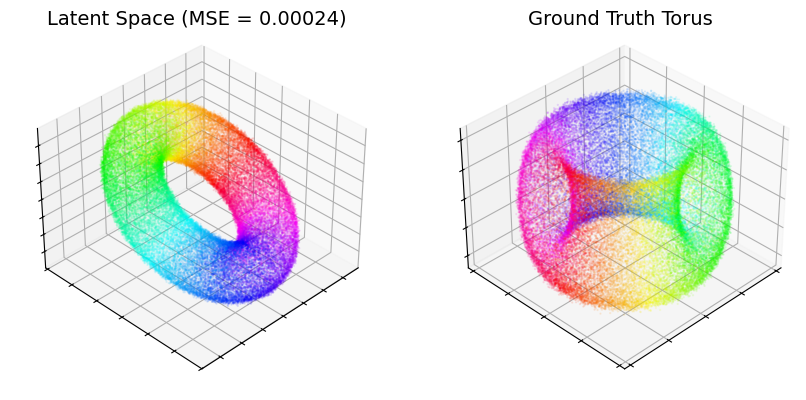


===== Summary =====
  Linear decoder     mean error: 0.00024


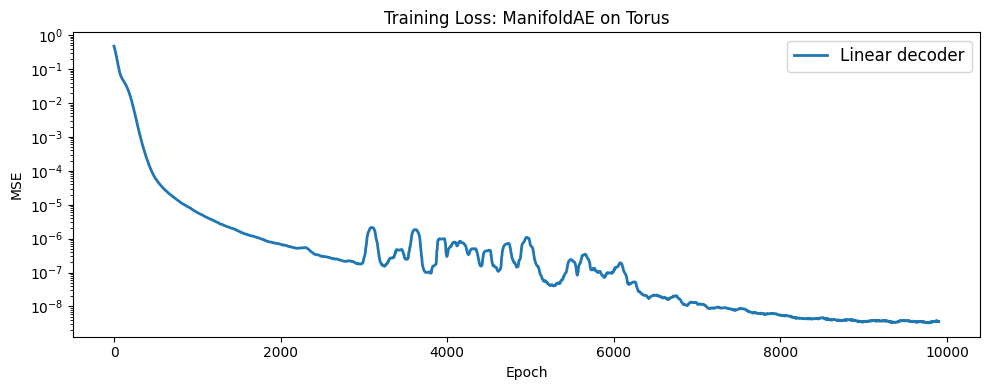

In [ ]:
# ============================================================
# Torus
# ============================================================

torch.manual_seed(42)

AMBIENT_DIM = 100
OVERCOMPLETE_DIM = 16
BOTTLENECK_DIM = 3
N_POINTS = 100000
EPOCHS = 10000

print(f"Generating T² in R^{AMBIENT_DIM}...")
X_high_tot, X_3d_tot, theta_tot, phi_tot = make_torus_embedded(
    n=N_POINTS, ambient_dim=AMBIENT_DIM
)

# Shuffle data before splitting
idx = torch.randperm(N_POINTS)
X_high_tot = X_high_tot[idx]
X_3d_tot = X_3d_tot[idx]
theta_tot = theta_tot[idx]
phi_tot = phi_tot[idx]

X_high = X_high_tot[:N_POINTS//2]
X_3d = X_3d_tot[:N_POINTS//2]
theta = theta_tot[:N_POINTS//2]
phi = phi_tot[:N_POINTS//2]

X_high_test = X_high_tot[N_POINTS//2:]
X_3d_test = X_3d_tot[N_POINTS//2:]
theta_test = theta_tot[N_POINTS//2:]
phi_test = phi_tot[N_POINTS//2:]

print(f"  Shape: {X_high.shape}")
print(f"  Range: [{X_high.min():.2f}, {X_high.max():.2f}]")

# ----- Model 1: Linear decoder -----
print("\n===== Linear Decoder =====")
# Compute geometric mean first to subtract - simulate SAELens
geometric_mean = torch.exp(torch.mean(X_high, dim=0))

model_lin = ManifoldAE(AMBIENT_DIM, OVERCOMPLETE_DIM, BOTTLENECK_DIM)

print(f"  params: {sum(p.numel() for p in model_lin.parameters()):,}")

losses_lin = train(model_lin, X_high , epochs=EPOCHS)
err_lin = visualize_torus(model_lin, X_high_test , X_3d_test, theta_test, phi_test,
                    "Linear Decoder")

xh, z = model_lin(X_high)

# ----- Comparison -----
print("\n===== Summary =====")
print(f"  Linear decoder     mean error: {err_lin.mean():.5f}")

fig, ax = plt.subplots(figsize=(10, 4))
w = 100
smooth = lambda x: np.convolve(x, np.ones(w)/w, mode='valid')
ax.semilogy(smooth(losses_lin), label='Linear decoder', linewidth=2)
ax.legend(fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training Loss: ManifoldAE on Torus')
plt.tight_layout()
plt.show()


Generating Helix in R^100...
  Shape: torch.Size([50000, 100])
  Range: [-2.65, 2.39]

===== Linear Decoder ManifoldAE =====
  params: 3,412
  epoch     0  loss=0.428842
  epoch  1000  loss=0.000002
  epoch  2000  loss=0.000000
  epoch  3000  loss=0.000000
  epoch  4000  loss=0.000000
  epoch  5000  loss=0.000000
  epoch  6000  loss=0.000000
  epoch  7000  loss=0.000000
  epoch  8000  loss=0.000000
  epoch  9000  loss=0.000000


/tmp/ipykernel_514/3758257545.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0.5)


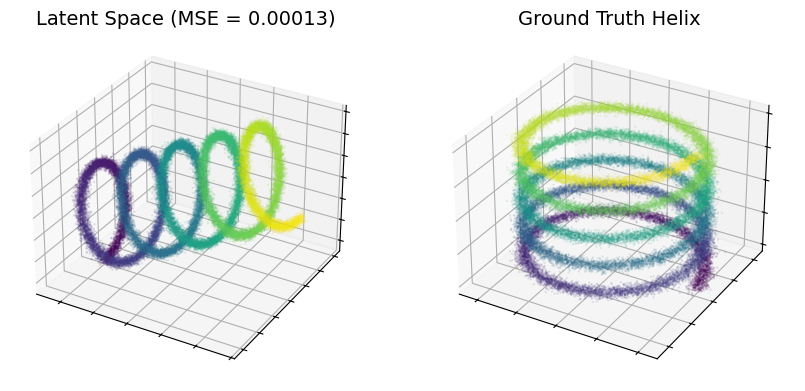


===== Summary =====
  Linear decoder mean error: 0.00013


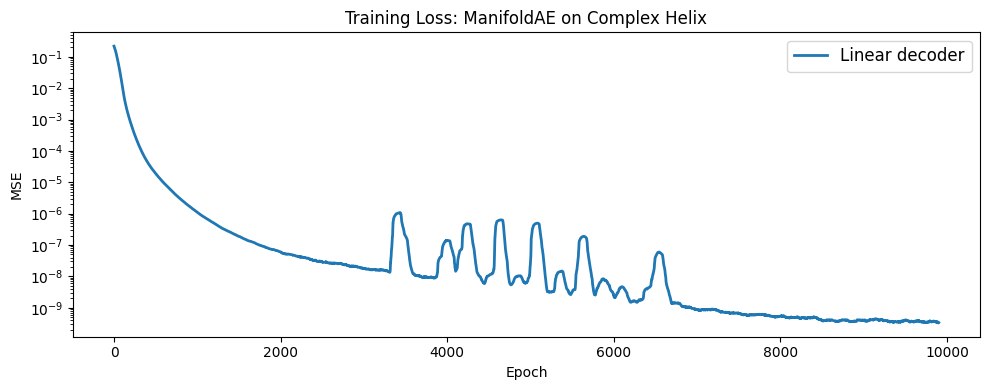

In [ ]:
# ============================================================
# Helix
# ============================================================

torch.manual_seed(42)

AMBIENT_DIM = 100
OVERCOMPLETE_DIM = 16
BOTTLENECK_DIM = 3
N_POINTS = 100000
EPOCHS = 10000

print(f"Generating Helix in R^{AMBIENT_DIM}...")
X_high_tot, X_3d_tot, t_tot, phase_tot = make_helix_embedded(
    n=N_POINTS, ambient_dim=AMBIENT_DIM
)

# Shuffle data before splitting
idx = torch.randperm(N_POINTS)
X_high_tot = X_high_tot[idx]
X_3d_tot = X_3d_tot[idx]
t_tot = t_tot[idx]
phase_tot = phase_tot[idx]

X_high = X_high_tot[:N_POINTS//2]
X_3d = X_3d_tot[:N_POINTS//2]
t_vals = t_tot[:N_POINTS//2]
phase_vals = phase_tot[:N_POINTS//2]

X_high_test = X_high_tot[N_POINTS//2:]
X_3d_test = X_3d_tot[N_POINTS//2:]
t_test = t_tot[N_POINTS//2:]
phase_test = phase_tot[N_POINTS//2:]

print(f"  Shape: {X_high.shape}")
print(f"  Range: [{X_high.min():.2f}, {X_high.max():.2f}]")

print("\n===== Linear Decoder ManifoldAE =====")

model_lin = ManifoldAE(AMBIENT_DIM, OVERCOMPLETE_DIM, BOTTLENECK_DIM)

print(f"  params: {sum(p.numel() for p in model_lin.parameters()):,}")

losses_lin = train(model_lin, X_high, epochs=EPOCHS)
err_lin = visualize_helix(model_lin, X_high_test, X_3d_test, t_test, phase_test,
                    "Linear Decoder (16 Latents)")

print("\n===== Summary =====")
print(f"  Linear decoder mean error: {err_lin.mean():.5f}")

fig, ax = plt.subplots(figsize=(10, 4))
w = 100
smooth = lambda x: np.convolve(x, np.ones(w)/w, mode='valid')
ax.semilogy(smooth(losses_lin), label='Linear decoder', linewidth=2)
ax.legend(fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training Loss: ManifoldAE on Complex Helix')
plt.tight_layout()
plt.show()
